In [8]:
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Definir a cor das bordas (spines) como cinza
mpl.rcParams['axes.edgecolor'] = 'gray'

# Definir a cor das linhas dos ticks maiores e menores como cinza
mpl.rcParams['xtick.color'] = 'gray'
mpl.rcParams['ytick.color'] = 'gray'
mpl.rcParams['xtick.labelcolor'] = 'black'
mpl.rcParams['ytick.labelcolor'] = 'black'
plt.rcParams['axes.labelsize'] = 16 # Axis labels
plt.rcParams['xtick.labelsize'] = 14  # X-axis tick labels
plt.rcParams['ytick.labelsize'] = 14  # Y-axis tick labels
plt.rcParams['font.size'] = 16  # General font size
FONT = 12

In [2]:
df = pd.read_csv('dengue_state.csv.gz')
df = df.groupby('date')[['casos']].sum().reset_index()
df.date = pd.to_datetime(df.date)
df.head()

,date,casos
0,2010-01-03,19724
1,2010-01-10,23690
2,2010-01-17,25814
3,2010-01-24,29104
4,2010-01-31,32698


/tmp/ipykernel_69316/1123420715.py:158: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


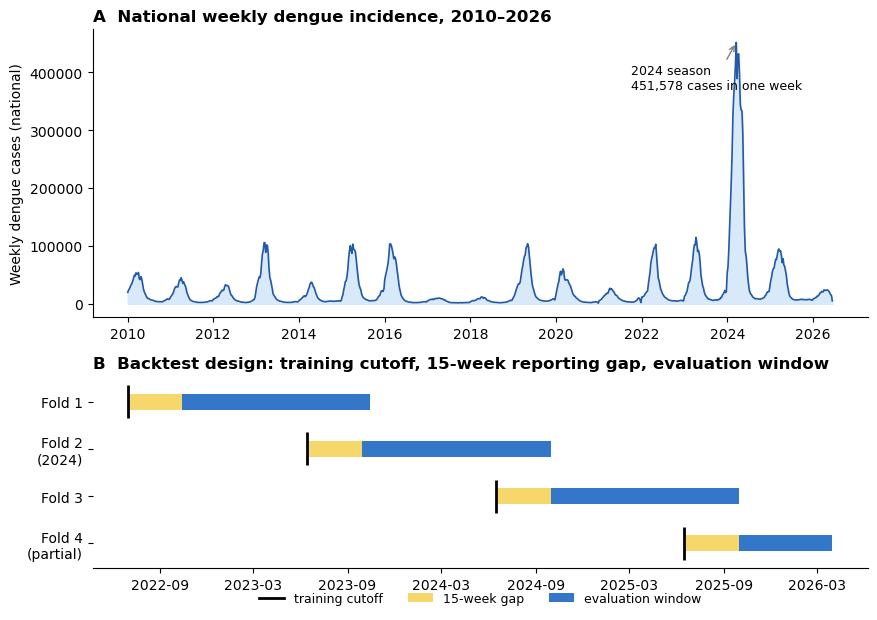

In [3]:

# -----------------------------------------------------------------------------
# Exemplo
# df deve possuir:
# date  -> datetime
# cases -> número de casos
# -----------------------------------------------------------------------------

# df = pd.read_csv(...)
# df["date"] = pd.to_datetime(df["date"])

fig = plt.figure(figsize=(10, 7))
gs = fig.add_gridspec(
    nrows=2,
    ncols=1,
    height_ratios=[3, 2],
    hspace=0.25
)

# =============================================================================
# Painel A
# =============================================================================
ax1 = fig.add_subplot(gs[0])

ax1.fill_between(
    df["date"],
    df["casos"],
    color="#d8e9fa"
)

ax1.plot(
    df["date"],
    df["casos"],
    color="#2459a6",
    lw=1.2
)

ax1.set_ylabel("Weekly dengue cases (national)")
ax1.set_title(
    "A  National weekly dengue incidence, 2010–2026",
    loc="left",
    fontweight="bold"
)

ax1.xaxis.set_major_locator(mdates.YearLocator(2))
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

ax1.spines[['top','right']].set_visible(False)

# Anotação do pico
peak = df.loc[df["casos"].idxmax()]

ax1.annotate(
    f"2024 season\n{peak.casos:,.0f} cases in one week",
    xy=(peak.date, peak.casos),
    xytext=(peak.date - pd.Timedelta(days=900), peak.casos*0.82),
    arrowprops=dict(
        arrowstyle="->",
        color="gray"
    ),
    fontsize=9
)

# =============================================================================
# Painel B
# =============================================================================

ax2 = fig.add_subplot(gs[1])

folds = [
    {
        "label":"Fold 1",
        "train":"2022-07-01",
        "gap_end":"2022-10-15",
        "eval_end":"2023-10-15"
    },
    {
        "label":"Fold 2\n(2024)",
        "train":"2023-06-15",
        "gap_end":"2023-09-30",
        "eval_end":"2024-09-30"
    },
    {
        "label":"Fold 3",
        "train":"2024-06-15",
        "gap_end":"2024-09-30",
        "eval_end":"2025-09-30"
    },
    {
        "label":"Fold 4\n(partial)",
        "train":"2025-06-15",
        "gap_end":"2025-09-30",
        "eval_end":"2026-03-31"
    }
]

height = 0.35

for i, fold in enumerate(folds[::-1]):

    y = i

    train = pd.Timestamp(fold["train"])
    gap_end = pd.Timestamp(fold["gap_end"])
    eval_end = pd.Timestamp(fold["eval_end"])

    # linha do corte
    ax2.vlines(train, y-height, y+height, color="black", lw=2)

    # gap
    ax2.broken_barh(
        [(mdates.date2num(train),
          mdates.date2num(gap_end)-mdates.date2num(train))],
        (y-height/2, height),
        facecolors="#f6d76b"
    )

    # avaliação
    ax2.broken_barh(
        [(mdates.date2num(gap_end),
          mdates.date2num(eval_end)-mdates.date2num(gap_end))],
        (y-height/2, height),
        facecolors="#3477c9"
    )

ax2.set_yticks(range(len(folds)))
ax2.set_yticklabels([f["label"] for f in folds[::-1]])

ax2.set_title(
    "B  Backtest design: training cutoff, 15-week reporting gap, evaluation window",
    loc="left",
    fontweight="bold"
)

ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

ax2.spines[['top','right','left']].set_visible(False)

# Legenda
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

legend = [
    Line2D([0],[0], color="black", lw=2, label="training cutoff"),
    Patch(facecolor="#f6d76b", label="15-week gap"),
    Patch(facecolor="#3477c9", label="evaluation window")
]

ax2.legend(
    handles=legend,
    ncol=3,
    frameon=False,
    loc="lower center",
    bbox_to_anchor=(0.5,-0.25),
    fontsize=9
)

plt.tight_layout()
plt.show()

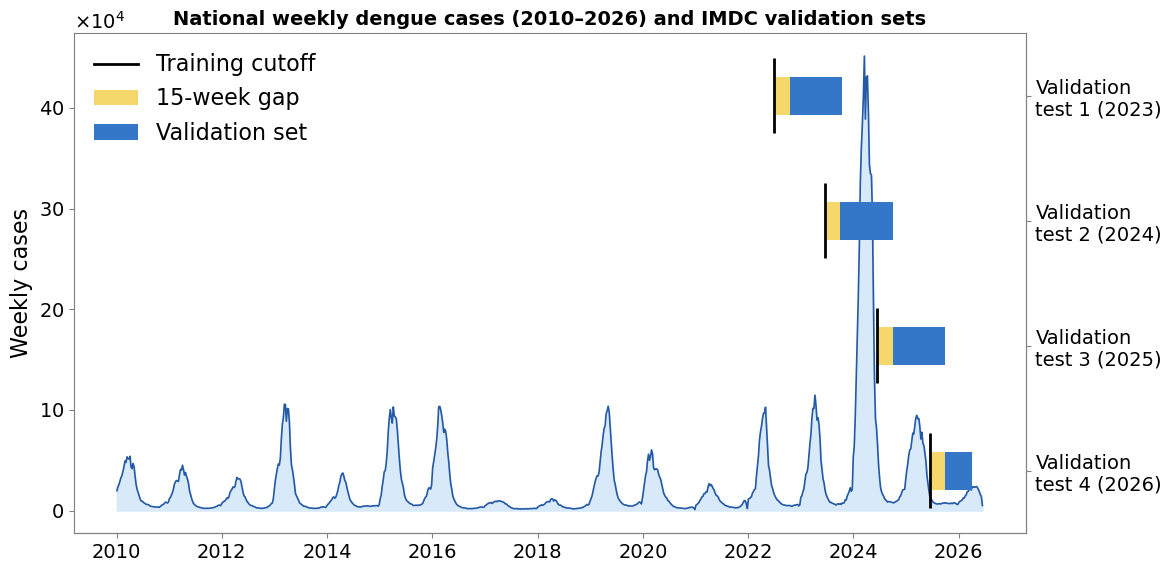

In [14]:
fig, ax1 = plt.subplots(figsize=(12,6))

# =============================================================================
# Casos
# =============================================================================

ax1.fill_between(
    df["date"],
    df["casos"],
    color="#d8e9fa"
)

ax1.plot(
    df["date"],
    df["casos"],
    color="#2459a6",
    lw=1.2
)

ax1.set_ylabel("Weekly cases")
ax1.set_title(
    "National weekly dengue cases (2010–2026) and IMDC validation sets",
    fontweight="bold",
    fontsize = 14
)

ax1.xaxis.set_major_locator(mdates.YearLocator(2))
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

# =============================================================================
# Segundo eixo para os folds
# =============================================================================

ax_fold = ax1.twinx()

folds = [
    {
        "label":"Validation\ntest 1 (2023)",
        "train":"2022-07-01",
        "gap_end":"2022-10-15",
        "eval_end":"2023-10-15"
    },
    {
        "label":"Validation\ntest 2 (2024)",
        "train":"2023-06-15",
        "gap_end":"2023-09-30",
        "eval_end":"2024-09-30"
    },
    {
        "label":"Validation\ntest 3 (2025)",
        "train":"2024-06-15",
        "gap_end":"2024-09-30",
        "eval_end":"2025-09-30"
    },
    {
        "label":"Validation\ntest 4 (2026)",
        "train":"2025-06-15",
        "gap_end":"2025-09-30",
        "eval_end":"2026-03-31"
    }
]

height = 0.3

for i, fold in enumerate(folds):

    train = pd.Timestamp(fold["train"])
    gap_end = pd.Timestamp(fold["gap_end"])
    eval_end = pd.Timestamp(fold["eval_end"])

    # linha do corte
    ax_fold.vlines(train, i-height, i+height, color="black", lw=2)

    # gap
    ax_fold.broken_barh(
        [(mdates.date2num(train),
          mdates.date2num(gap_end)-mdates.date2num(train))],
        (i-height/2, height),
        facecolors="#f6d76b"
    )

    # avaliação
    ax_fold.broken_barh(
        [(mdates.date2num(gap_end),
          mdates.date2num(eval_end)-mdates.date2num(gap_end))],
        (i-height/2, height),
        facecolors="#3477c9"
    )

ax_fold.set_ylim(-0.5, len(folds)-0.5)
ax_fold.set_yticks(range(len(folds)))
ax_fold.set_yticklabels([f["label"] for f in folds])

# Coloca o primeiro fold no topo
ax_fold.invert_yaxis()

# Esconde a moldura do segundo eixo
ax_fold.spines["top"].set_visible(False)
ax_fold.spines["left"].set_visible(False)

# Legenda
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

legend = [
    Line2D([0],[0], color="black", lw=2, label="Training cutoff"),
    Patch(facecolor="#f6d76b", label="15-week gap"),
    Patch(facecolor="#3477c9", label="Validation set")
]

ax1.legend(
    handles=legend,
    loc="upper left",
    frameon=False
)

from matplotlib.ticker import ScalarFormatter

formatter = ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((4, 4))   # força o fator 10^4

ax1.yaxis.set_major_formatter(formatter)

plt.tight_layout()
plt.savefig('validation_sets.png', dpi = 300, bbox_inches = 'tight')
plt.show()